# Data Understanding

## 1. Sumber Data

Data polutan udara yang digunakan dalam analisis ini diperoleh dari [dataspace.copernicus.eu](https://dataspace.copernicus.eu/). Data berasal dari pengamatan satelit Sentinel-5P yang diakses melalui layanan openEO.

Pengambilan data dilakukan dengan menentukan wilayah pengamatan menggunakan Area of Interest (AOI). AOI digunakan untuk membatasi wilayah data sehingga analisis difokuskan pada Kabupaten Bangkalan, Jawa Timur. Dengan periode 30 Agustus 2025 - 30 Agustus 2026

## 2. Penentuan Wilayah Pengamatan

Wilayah pengamatan dalam analisis ini adalah Kabupaten Bangkalan, Jawa Timur. Untuk membatasi data agar sesuai dengan wilayah kajian, digunakan Area of Interest (AOI) dalam bentuk polygon.

Polygon AOI dibentuk berdasarkan koordinat geografis yang merepresentasikan wilayah Kabupaten Bangkalan. Koordinat tersebut digunakan sebagai batas spasial dalam proses pengambilan data, koordinat menggunakan alat bantu pemetaan [geojson.io](https://geojson.io/). Setiap titik koordinat pada polygon menggunakan format [longitude, latitude], sehingga posisi geografis wilayah dapat ditentukan secara lebih spesifik.

|  Atribut     |   Nilai                 | Keterangan|
| :------------| :---------------------- | :----------------------
|west          | 112.6751542      |Longitude terkecil (batas kiri)|
|south         | -7.2320899              |Latitude terkecil (batas bawah)|
|east          | 113.1302065             |Longitude terbesar (batas kanan)|
|north         | -6.8663627              |Latitude terbesar (batas atas)|


## 3. Pengumpulan Data

### Install Library

Untuk melakukan proses crawling data, kita membutuhkan pustaka Python pendukung yaitu openeo untuk berkomunikasi dengan API Copernicus.

In [1]:
pip install openeo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


### Koneksi dan Otentikasi
Langkah pertama adalah menghubungkan ke server openEO dan melakukan otentikasi menggunakan akun Copernicus Data Space.

In [2]:
import openeo

connection = openeo.connect("openeo.dataspace.copernicus.eu").authenticate_oidc()

Visit https://identity.dataspace.copernicus.eu/auth/realms/CDSE/device?user_code=OUTU-AAPD 📋 to authenticate.

❌ Timed out

OidcDeviceCodePollTimeout: Timeout (300.0s) while polling for access token.

Klik link autentikasi lalu login menggunakan akun Copernicus.

### Pengambilan Data

Data dikumpulkan menggunakan layanan openEO dengan koleksi Sentinel-5P. Proses pengambilan data dilakukan berdasarkan wilayah AOI Kabupaten Bangkalan dan periode pengamatan yang telah ditentukan.

In [12]:
aoi = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              112.6751542,
              -6.8663627
            ],
            [
              113.1302065,
              -6.8663627
            ],
            [
              113.1302065,
              -7.2320899
            ],
            [
              112.6751542,
              -7.2320899
            ],
            [
              112.6751542,
              -6.8663627
            ]
          ]
        ]
      }
    }
  ]
}

Data kemudian diagregasi berdasarkan waktu untuk memperoleh nilai rata-rata harian. Selanjutnya dilakukan agregasi spasial pada area AOI sehingga diperoleh satu nilai yang merepresentasikan kondisi rata-rata wilayah pada setiap waktu pengamatan.

#### 1. NO2

In [13]:
s5NO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-30", "2026-08-30"],
    spatial_extent={
        "west": 112.6751542,
        "south": -7.2320899,
        "east": 113.1302065,
        "north": -6.8663627
    },
    bands=["NO2"],
)

# Agregasi harian
s5p_NO2_daily = s5NO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial berdasarkan AOI
s5p_NO2_aoi = s5p_NO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

Hasil pengolahan kemudian disimpan dalam format CSV.

In [14]:
# Simpan hasil sebagai CSV
result_NO2 = s5p_NO2_aoi.save_result(
    format="CSV"
)

# Jalankan job
job_NO2 = result_NO2.create_job(
    title="s5p_NO2_timeseries"
)

job_NO2.start_and_wait()

# Download CSV
job_NO2.get_results().download_files("output_NO2")

0:00:00 Job 'j-2608301629214c98a68cb85e50fac22d': send 'start'
0:00:02 Job 'j-2608301629214c98a68cb85e50fac22d': created (progress 0%)
0:00:07 Job 'j-2608301629214c98a68cb85e50fac22d': queued (progress 0%)
0:00:14 Job 'j-2608301629214c98a68cb85e50fac22d': queued (progress 0%)
0:00:22 Job 'j-2608301629214c98a68cb85e50fac22d': queued (progress 0%)
0:00:31 Job 'j-2608301629214c98a68cb85e50fac22d': queued (progress 0%)
0:00:44 Job 'j-2608301629214c98a68cb85e50fac22d': queued (progress 0%)
0:00:59 Job 'j-2608301629214c98a68cb85e50fac22d': queued (progress 0%)
0:01:18 Job 'j-2608301629214c98a68cb85e50fac22d': queued (progress 0%)
0:01:42 Job 'j-2608301629214c98a68cb85e50fac22d': running (progress N/A)
0:02:12 Job 'j-2608301629214c98a68cb85e50fac22d': running (progress N/A)
0:02:50 Job 'j-2608301629214c98a68cb85e50fac22d': running (progress N/A)
0:03:36 Job 'j-2608301629214c98a68cb85e50fac22d': running (progress N/A)
0:04:34 Job 'j-2608301629214c98a68cb85e50fac22d': running (progress N/A)
0:0

[PosixPath('output_NO2/timeseries.csv'),
 PosixPath('output_NO2/job-results.json')]

#### 2. CO

In [15]:
s5CO = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-30", "2026-08-30"],
    spatial_extent={
        "west": 112.6751542,
        "south": -7.2320899,
        "east": 113.1302065,
        "north": -6.8663627
    },
    bands=["CO"],
)

# Agregasi harian
s5p_CO_daily = s5CO.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial berdasarkan AOI
s5p_CO_aoi = s5p_CO_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

In [16]:
# Simpan hasil sebagai CSV
result_CO = s5p_CO_aoi.save_result(
    format="CSV"
)

# Jalankan job
job_CO = result_CO.create_job(
    title="s5p_CO_timeseries"
)

job_CO.start_and_wait()

# Download CSV
job_CO.get_results().download_files("output_CO")

0:00:00 Job 'j-26083016345946ab9f15644b35eb2e98': send 'start'
0:00:02 Job 'j-26083016345946ab9f15644b35eb2e98': created (progress 0%)
0:00:07 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:00:13 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:00:21 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:00:31 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:00:44 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:00:59 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:01:18 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:01:42 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:02:12 Job 'j-26083016345946ab9f15644b35eb2e98': queued (progress 0%)
0:02:49 Job 'j-26083016345946ab9f15644b35eb2e98': running (progress N/A)
0:03:36 Job 'j-26083016345946ab9f15644b35eb2e98': running (progress N/A)
0:04:34 Job 'j-26083016345946ab9f15644b35eb2e98': running (progress N/A)
0:05:34

[PosixPath('output_CO/timeseries.csv'),
 PosixPath('output_CO/job-results.json')]

#### 3. S02

In [17]:
s5SO2 = connection.load_collection(
    "SENTINEL_5P_L2",
    temporal_extent=["2025-08-30", "2026-08-30"],
    spatial_extent={
        "west": 112.6751542,
        "south": -7.2320899,
        "east": 113.1302065,
        "north": -6.8663627
    },
    bands=["SO2"],
)

# Agregasi harian
s5p_SO2_daily = s5SO2.aggregate_temporal_period(
    reducer="mean",
    period="day"
)

# Agregasi spasial berdasarkan AOI
s5p_SO2_aoi = s5p_SO2_daily.aggregate_spatial(
    reducer="mean",
    geometries=aoi
)

In [18]:
# Simpan hasil sebagai CSV
result_SO2 = s5p_SO2_aoi.save_result(
    format="CSV"
)

# Jalankan job
job_SO2 = result_SO2.create_job(
    title="s5p_SO2_timeseries"
)

job_SO2.start_and_wait()

# Download CSV
job_SO2.get_results().download_files("output_SO2")

0:00:00 Job 'j-26083016403543c88bce07f48d464319': send 'start'
0:00:03 Job 'j-26083016403543c88bce07f48d464319': created (progress 0%)
0:00:08 Job 'j-26083016403543c88bce07f48d464319': queued (progress 0%)
0:00:14 Job 'j-26083016403543c88bce07f48d464319': queued (progress 0%)
0:00:22 Job 'j-26083016403543c88bce07f48d464319': queued (progress 0%)
0:00:32 Job 'j-26083016403543c88bce07f48d464319': queued (progress 0%)
0:00:44 Job 'j-26083016403543c88bce07f48d464319': running (progress N/A)
0:01:00 Job 'j-26083016403543c88bce07f48d464319': running (progress N/A)
0:01:19 Job 'j-26083016403543c88bce07f48d464319': running (progress N/A)
0:01:43 Job 'j-26083016403543c88bce07f48d464319': running (progress N/A)
0:02:13 Job 'j-26083016403543c88bce07f48d464319': running (progress N/A)
0:02:50 Job 'j-26083016403543c88bce07f48d464319': running (progress N/A)
0:03:37 Job 'j-26083016403543c88bce07f48d464319': finished (progress 100%)


[PosixPath('output_SO2/timeseries.csv'),
 PosixPath('output_SO2/job-results.json')]

### Tampilan Data CSV

In [27]:
import pandas as pd

# Membaca masing-masing CSV
df_CO = pd.read_csv("./mystorage/output_CO/timeseries.csv")
df_NO2 = pd.read_csv("./mystorage/output_NO2/timeseries.csv")
df_SO2 = pd.read_csv("./mystorage/output_SO2/timeseries.csv")

# Melihat struktur masing-masing data
print("CO:")
display(df_CO.head(5))

print("NO₂:")
display(df_NO2.head(5))

print("SO₂:")
display(df_SO2.head(5))

CO:


,date,feature_index,CO
0,2025-09-25T00:00:00.000Z,0,0.027630
1,2025-09-27T00:00:00.000Z,0,0.034706
2,2025-09-23T00:00:00.000Z,0,0.033936
3,2025-09-24T00:00:00.000Z,0,0.037339
4,2025-09-21T00:00:00.000Z,0,0.029730


NO₂:


,date,feature_index,NO2
0,2026-08-28T00:00:00.000Z,0,0.000030
1,2026-08-25T00:00:00.000Z,0,0.000022
2,2026-08-27T00:00:00.000Z,0,0.000030
3,2026-08-24T00:00:00.000Z,0,0.000028
4,2026-08-29T00:00:00.000Z,0,0.000022


SO₂:


,date,feature_index,SO2
0,2026-03-03T00:00:00.000Z,0,-0.000029
1,2026-03-05T00:00:00.000Z,0,0.000034
2,2026-03-06T00:00:00.000Z,0,0.000008
3,2026-03-02T00:00:00.000Z,0,NaN
4,2026-03-01T00:00:00.000Z,0,0.000116


## 4. Eksplorasi Data

### Pemeriksaan Missing Values

Pemeriksaan missing values dilakukan untuk mengetahui kelengkapan data konsentrasi masing-masing polutan. Pemeriksaan ini penting karena tidak semua hari dalam periode pengamatan memiliki nilai konsentrasi polutan.

Berdasarkan hasil pemeriksaan awal, seluruh dataset memiliki 366 baris. Namun, jumlah data yang tersedia pada masing-masing parameter berbeda. Hal tersebut menunjukkan bahwa terdapat beberapa waktu pengamatan yang tidak memiliki nilai konsentrasi polutan.

In [30]:
# Menghitung missing values
missing_CO = df_CO["CO"].isna().sum()
missing_NO2 = df_NO2["NO2"].isna().sum()
missing_SO2 = df_SO2["SO2"].isna().sum()

print("Missing values CO  :", missing_CO)
print("Missing values NO₂ :", missing_NO2)
print("Missing values SO₂ :", missing_SO2)

Missing values CO  : 87
Missing values NO₂ : 74
Missing values SO₂ : 44


### Identifikasi Outlier

Outlier merupakan nilai pengamatan yang memiliki karakteristik berbeda atau berada jauh dari sebagian besar distribusi data. Dalam analisis kualitas udara, nilai yang tinggi tidak selalu berarti kesalahan data karena dapat menunjukkan kondisi tertentu pada waktu pengamatan.

Oleh karena itu, pada tahap Data Understanding, outlier hanya diidentifikasi dan tidak langsung dihapus. Identifikasi dilakukan menggunakan metode Interquartile Range (IQR), yaitu dengan menentukan batas bawah dan batas atas berdasarkan kuartil pertama (Q1) dan kuartil ketiga (Q3).

In [ ]:
!pip install matplotlib

In [40]:
import pandas as pd

# Membaca masing-masing CSV
df_CO = pd.read_csv("./mystorage/output_CO/timeseries.csv")
df_NO2 = pd.read_csv("./mystorage/output_NO2/timeseries.csv")
df_SO2 = pd.read_csv("./mystorage/output_SO2/timeseries.csv")

# Mengubah kolom date menjadi datetime
df_CO["date"] = pd.to_datetime(df_CO["date"])
df_NO2["date"] = pd.to_datetime(df_NO2["date"])
df_SO2["date"] = pd.to_datetime(df_SO2["date"])

# Menggabungkan berdasarkan tanggal
df = df_CO[["date", "CO"]].merge(
    df_NO2[["date", "NO2"]],
    on="date",
    how="outer"
).merge(
    df_SO2[["date", "SO2"]],
    on="date",
    how="outer"
)

# Mengurutkan berdasarkan tanggal
df = df.sort_values("date").reset_index(drop=True)

# Melihat hasil
display(df.head())

,date,CO,NO2,SO2
0,2025-08-29 00:00:00+00:00,NaN,NaN,NaN
1,2025-08-30 00:00:00+00:00,0.025453,0.000020,0.000003
2,2025-08-31 00:00:00+00:00,0.025945,0.000015,-0.000005
3,2025-09-01 00:00:00+00:00,0.026809,0.000019,0.000017
4,2025-09-02 00:00:00+00:00,0.024403,0.000014,-0.000035


In [44]:
# IDENTIFIKASI OUTLIER MENGGUNAKAN IQR

polutan = ["CO", "NO2", "SO2"]

hasil_outlier = []
data_outlier = {}

for kolom in polutan:
    data = df[["date", kolom]].dropna()

    Q1 = data[kolom].quantile(0.25)
    Q3 = data[kolom].quantile(0.75)
    IQR = Q3 - Q1

    batas_bawah = Q1 - 1.5 * IQR
    batas_atas = Q3 + 1.5 * IQR

    outlier = data[
        (data[kolom] < batas_bawah) |
        (data[kolom] > batas_atas)
    ]

    hasil_outlier.append({
        "Polutan": kolom,
        "Jumlah Data": len(data),
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Batas Bawah": batas_bawah,
        "Batas Atas": batas_atas,
        "Jumlah Outlier": len(outlier)
    })

    data_outlier[kolom] = outlier.sort_values(
        by=kolom,
        ascending=False
    )

# Tabel ringkasan
outlier_summary = pd.DataFrame(hasil_outlier)

print("=== OUTLIER ===")
display(outlier_summary)

=== OUTLIER ===


,Polutan,Jumlah Data,Q1,Q3,IQR,Batas Bawah,Batas Atas,Jumlah Outlier
0,CO,279,0.026708,0.030267,0.003560,0.021368,0.035607,5
1,NO2,292,0.000020,0.000031,0.000011,0.000004,0.000046,10
2,SO2,322,-0.000011,0.000100,0.000111,-0.000177,0.000266,29


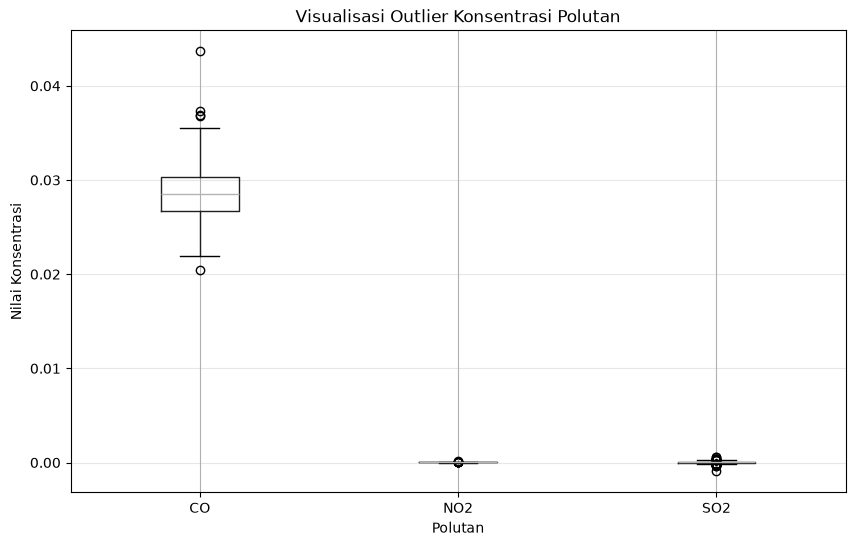

In [45]:
import matplotlib.pyplot as plt

# Visualisasi boxplot CO, NO₂, dan SO₂
plt.figure(figsize=(10, 6))

df[["CO", "NO2", "SO2"]].boxplot()

plt.title("Visualisasi Outlier Konsentrasi Polutan")
plt.xlabel("Polutan")
plt.ylabel("Nilai Konsentrasi")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Visualisasi Time Series

Visualisasi time series digunakan untuk menggambarkan perubahan konsentrasi polutan udara dari waktu ke waktu. Pada analisis ini, data yang digunakan merupakan data harian selama periode pengamatan 30 Agustus 2025 hingga 30 Agustus 2026. Kolom date digunakan sebagai sumbu waktu, sedangkan nilai masing-masing polutan digunakan sebagai nilai konsentrasi pada setiap tanggal pengamatan.

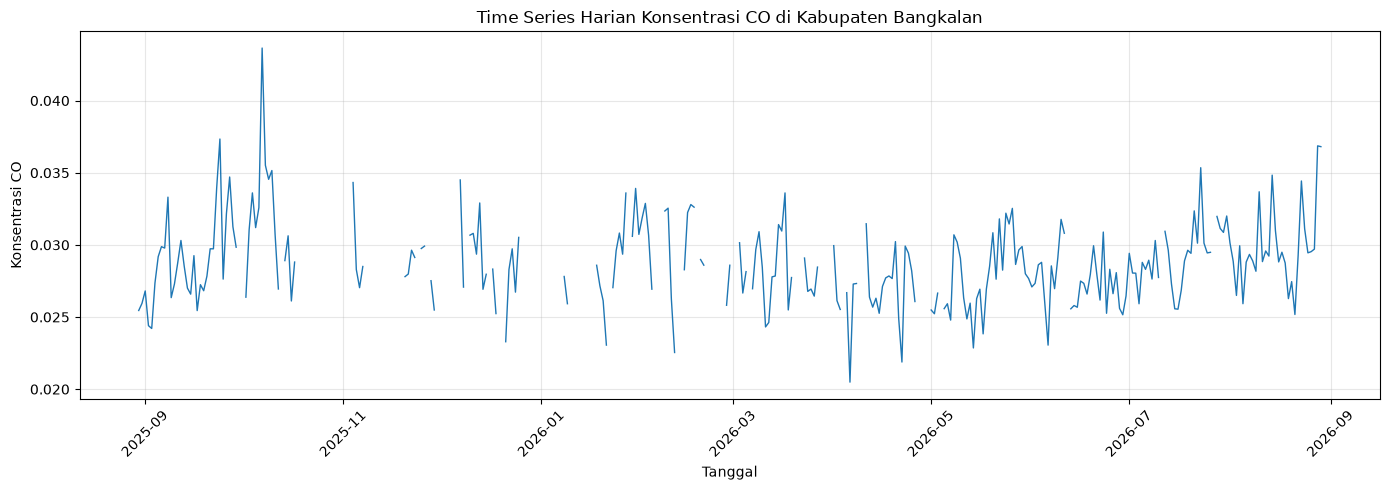

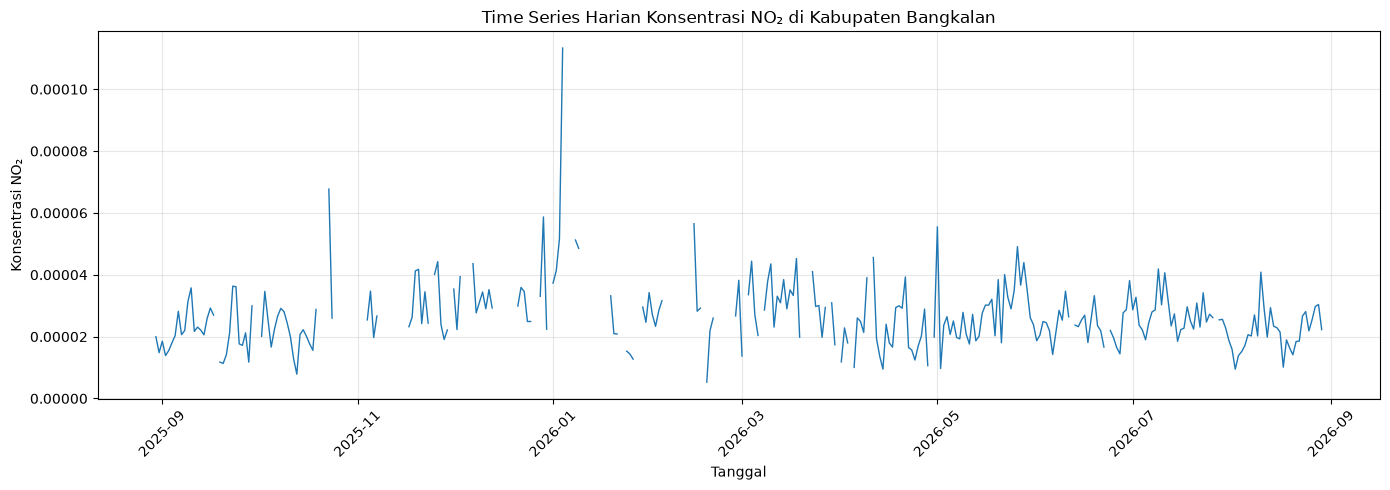

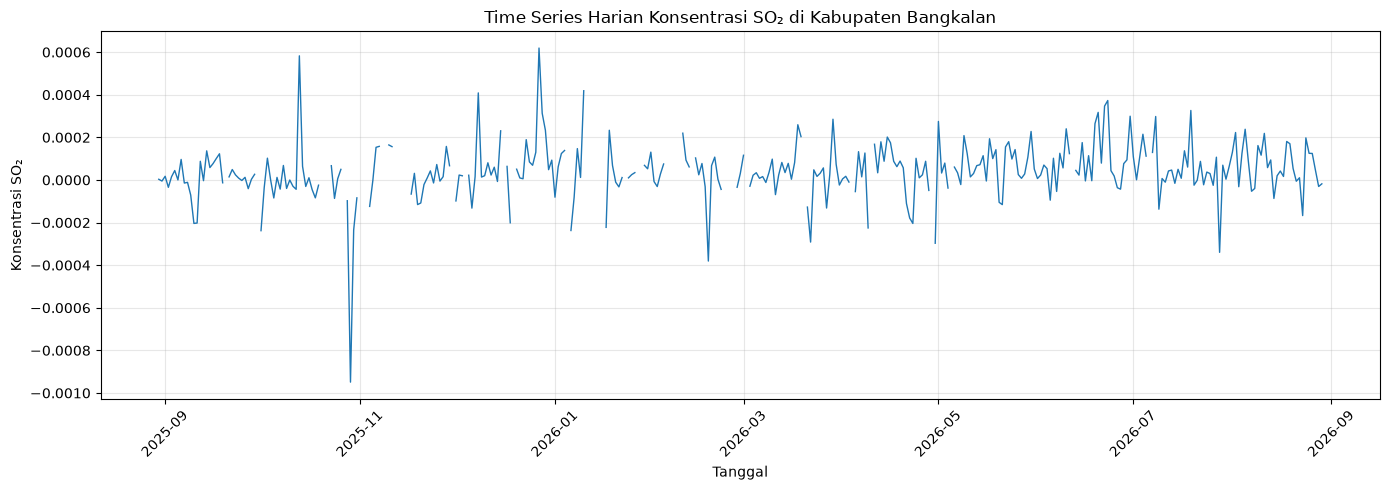

In [48]:
import matplotlib.pyplot as plt

# Memastikan kolom date sudah dalam format datetime
df["date"] = pd.to_datetime(df["date"])

# Mengurutkan data berdasarkan tanggal
df = df.sort_values("date")

# TIME SERIES CO

plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["CO"],
    linewidth=1
)

plt.title("Time Series Harian Konsentrasi CO di Kabupaten Bangkalan")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi CO")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TIME SERIES NO₂

plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["NO2"],
    linewidth=1
)

plt.title("Time Series Harian Konsentrasi NO₂ di Kabupaten Bangkalan")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi NO₂")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# TIME SERIES SO₂

plt.figure(figsize=(14, 5))

plt.plot(
    df["date"],
    df["SO2"],
    linewidth=1
)

plt.title("Time Series Harian Konsentrasi SO₂ di Kabupaten Bangkalan")
plt.xlabel("Tanggal")
plt.ylabel("Konsentrasi SO₂")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()